# What Drives High-Defect Production? — Python Analysis

Part 2 of the project (Part 1 is the SQL analysis in `../sql/`). SQL answered the stakeholder's business questions; this notebook goes further with distributions, correlations, hypothesis tests, a rule-based risk flag, a decision tree, and a summary dashboard.

**Stakeholder:** a Plant Operations Director deciding where to spend budget to reduce high-defect production.

**Data:** [Predicting Manufacturing Defects Dataset](https://www.kaggle.com/datasets/rabieelkharoua/predicting-manufacturing-defects-dataset) (Kaggle), 3,240 records × 17 numeric columns. `DefectStatus` is the label: 1 = high defects, 0 = low defects. Download the CSV into `../data/` to run this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_defects = pd.read_csv('../data/manufacturing_defect_dataset.csv')

print(df_defects.shape)
print('Missing values:', df_defects.isna().sum().sum())
print('Duplicate rows:', df_defects.duplicated().sum())
print('High-defect share:', round(df_defects['DefectStatus'].mean() * 100, 2), '%')

(3240, 17)
Missing values: 0
Duplicate rows: 0
High-defect share: 84.04 %


## 1. What do the distributions look like?

Whole-number columns with few values (maintenance hours, delivery delay, safety incidents) get **one bin per value**. With the default 20 bins, maintenance hours' 24 values produced four fake spikes where a bin held two hours instead of one.

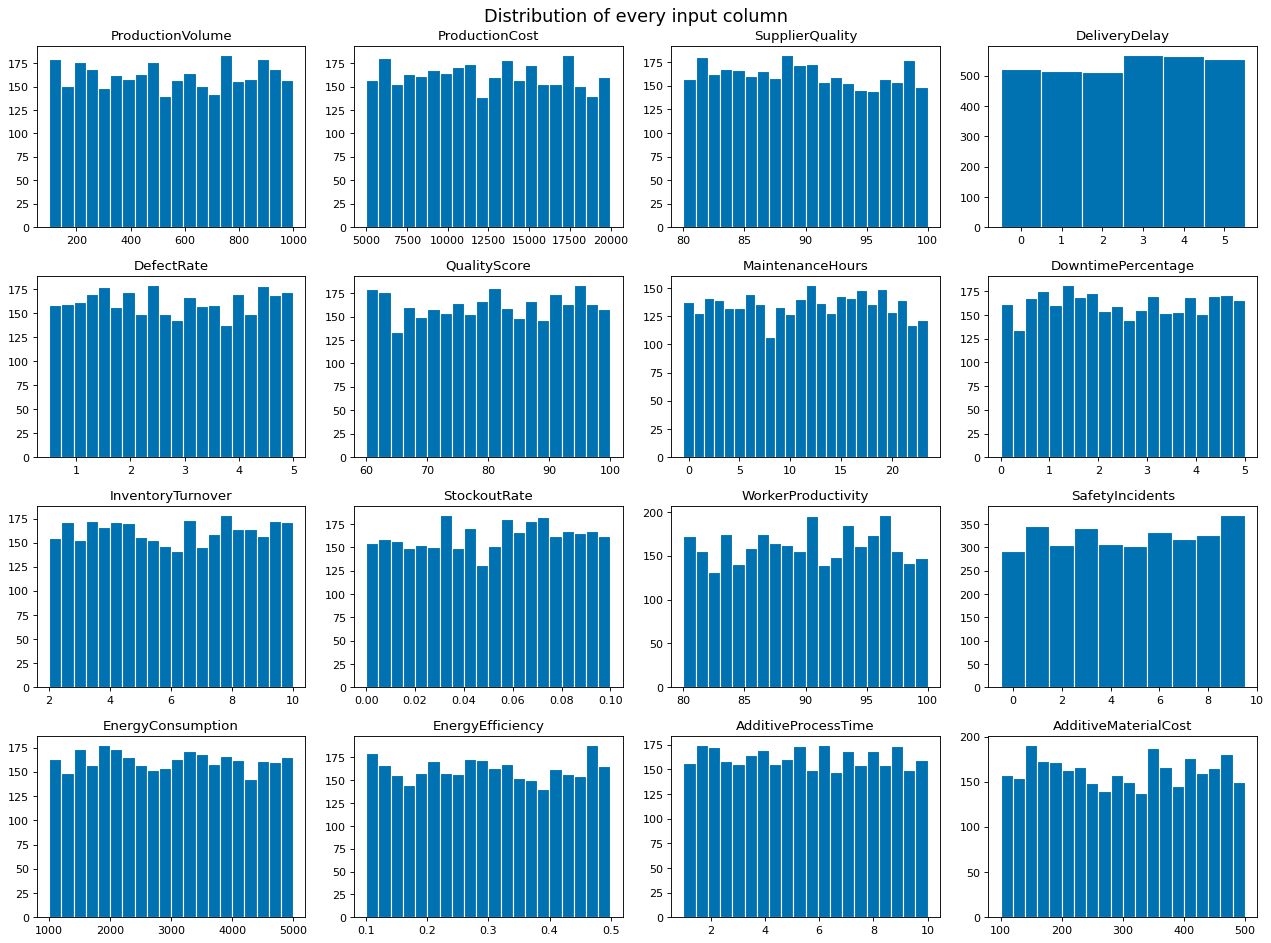

In [2]:
input_columns = df_defects.columns.drop('DefectStatus')

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flatten(), input_columns):
    values = df_defects[col]
    if values.nunique() <= 30:                                   # few whole-number values
        bins = np.arange(values.min() - 0.5, values.max() + 1.5, 1)
    else:                                                        # continuous measurement
        bins = 20
    ax.hist(values, bins=bins, color='#0072B2', edgecolor='white')
    ax.set_title(col)

fig.suptitle('Distribution of every input column', fontsize=16)
plt.tight_layout()
plt.show()

**Finding:** every column is close to **uniformly distributed** — values spread evenly between fixed limits, with no clustering around a target and no long tails. Real process data rarely looks like this, so the dataset is treated as **synthetic**: good for demonstrating methods, not for conclusions about a real plant.

## 2. Which factors relate to DefectStatus?

The color scale is centered at zero (`vmin=-1, vmax=1, center=0`) so near-zero cells fade to neutral and only real correlations get color. The mirrored upper half is hidden.

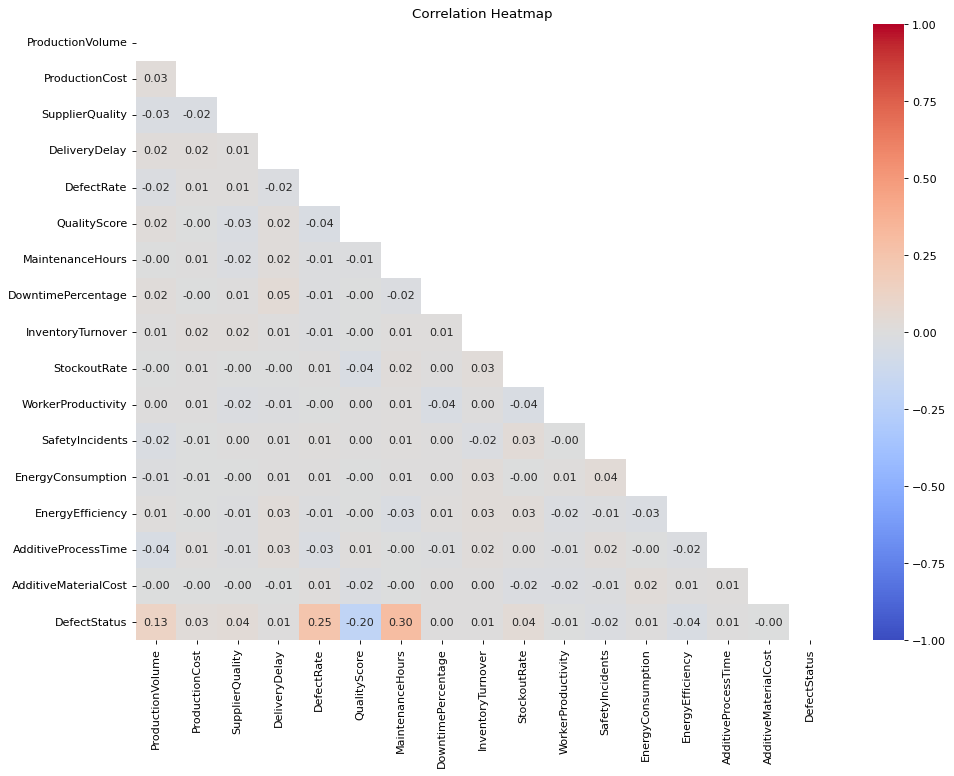

QualityScore           -0.199
EnergyEfficiency       -0.035
SafetyIncidents        -0.016
WorkerProductivity     -0.005
AdditiveMaterialCost   -0.001
DowntimePercentage      0.004
EnergyConsumption       0.005
DeliveryDelay           0.005
AdditiveProcessTime     0.006
InventoryTurnover       0.007
ProductionCost          0.027
SupplierQuality         0.038
StockoutRate            0.041
ProductionVolume        0.129
DefectRate              0.246
MaintenanceHours        0.297
Name: DefectStatus, dtype: float64


In [3]:
corr = df_defects.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.savefig('../images/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print(corr['DefectStatus'].drop('DefectStatus').sort_values().round(3))

**Finding:** only four factors stand out from the ±0.05 noise: **maintenance hours (0.30), defect rate (0.25), quality score (−0.20), production volume (0.13)**. The input factors are uncorrelated with each other, so each acts independently.

Correlation **understates** these effects: the SQL analysis showed they are sharp cliffs, not straight-line trends, and correlation only measures straight lines. The numbers rank the factors; they don't measure how strong the effects are.

### 2b. Quality score threshold — and closing the SQL question 9 loop

In SQL, 1,217 records were labeled high-defect despite a below-average defect rate, and two thresholds (maintenance > 10, volume > 800) explained only 84% of them. Quality score is the third suspect.

In [4]:
bins = range(60, 101, 5)
df_defects['QualityScore_bin'] = pd.cut(df_defects['QualityScore'], bins=bins, right=False)

quality_threshold = (
    df_defects.groupby('QualityScore_bin', observed=True)['DefectStatus'].mean() * 100
).round(2)
print(quality_threshold)

QualityScore_bin
[60, 65)     95.48
[65, 70)     96.04
[70, 75)     95.91
[75, 80)     77.59
[80, 85)     75.49
[85, 90)     78.17
[90, 95)     78.47
[95, 100)    76.42
Name: DefectStatus, dtype: float64


In [5]:
# Compare rates on each side of the cutoff, not raw counts
below = df_defects[df_defects['QualityScore'] < 75]
above = df_defects[df_defects['QualityScore'] >= 75]
print('Below 75:', len(below), 'records,', round(below['DefectStatus'].mean() * 100, 1), '% high-defect')
print('75+     :', len(above), 'records,', round(above['DefectStatus'].mean() * 100, 1), '% high-defect')

Below 75: 1190 records, 95.8 % high-defect
75+     : 2050 records, 77.2 % high-defect


In [6]:
avg_rate = df_defects['DefectRate'].mean()

mismatch = df_defects[
    (df_defects['DefectStatus'] == 1) &
    (df_defects['DefectRate'] < avg_rate)
]

explained = (
    (mismatch['MaintenanceHours'] > 10) |
    (mismatch['ProductionVolume'] > 800) |
    (mismatch['QualityScore'] < 75)
)

print('High-defect but below-average rate:', len(mismatch))
print('Explained by the three thresholds: ', explained.sum())
print('Share explained:', round(explained.mean() * 100, 2), '%')

High-defect but below-average rate: 1217
Explained by the three thresholds:  1204
Share explained: 98.93 %


**Finding:** below a quality score of 75, records are 96% high-defect; at 75 and above, 77%. Adding this third threshold explains **98.9%** of the puzzling records (up from 84% in SQL). The label behaves like a checklist of operational rules, not a measure of defects.

## 3. How do the key factors differ between low- and high-defect records?

The line inside each box is the **median**.

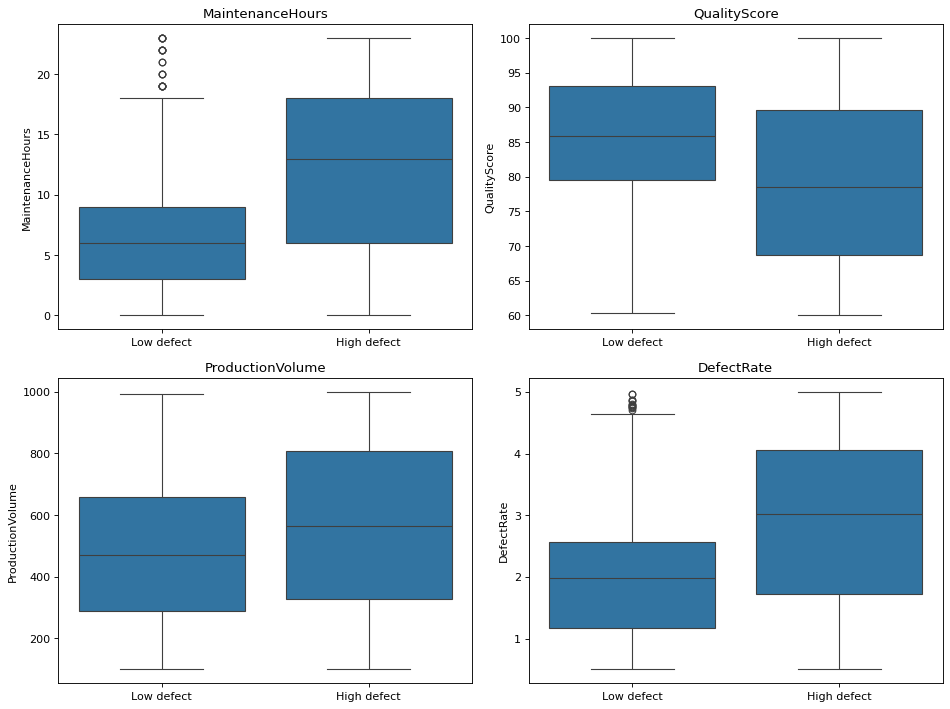

In [7]:
factors = ['MaintenanceHours', 'QualityScore', 'ProductionVolume', 'DefectRate']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, factor in zip(axes.flatten(), factors):
    sns.boxplot(data=df_defects, x='DefectStatus', y=factor, ax=ax)
    ax.set_xticks([0, 1], ['Low defect', 'High defect'])
    ax.set_title(factor)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

**Finding:** all four medians differ, with the largest gap in maintenance hours (about 6 vs. 13). But the boxes **overlap heavily**: a record becomes high-defect if *any one* threshold is crossed, so the high-defect group contains many records that look normal on each individual factor. No single factor separates the groups — the thresholds only work in combination.

## 4. Is there a tipping point in maintenance hours?

Seaborn averages per hour and draws a **95% confidence interval** (shaded band): how far each point could move by chance alone.

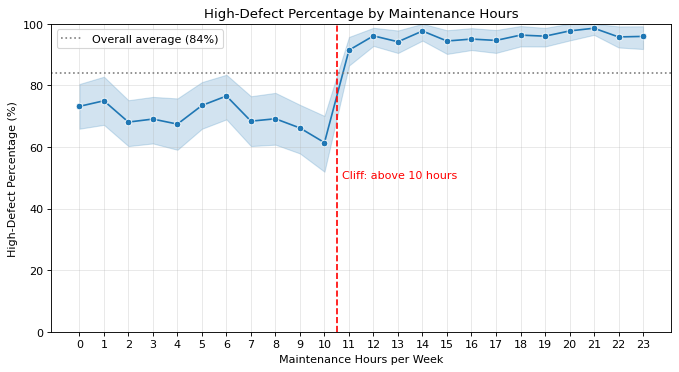

In [8]:
df_defects['high_defect_pct'] = df_defects['DefectStatus'] * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_defects, x='MaintenanceHours', y='high_defect_pct', marker='o')
plt.axvline(10.5, color='red', linestyle='--')
plt.text(10.7, 50, 'Cliff: above 10 hours', color='red')
plt.axhline(84, color='grey', linestyle=':', label='Overall average (84%)')
plt.ylim(0, 100)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.title('High-Defect Percentage by Maintenance Hours')
plt.xlabel('Maintenance Hours per Week')
plt.ylabel('High-Defect Percentage (%)')
plt.legend()
plt.savefig('../images/maintenance_tipping_point.png', dpi=120, bbox_inches='tight')
plt.show()

**Finding:** flat at about 70% for 0–10 hours, then a jump to about 95% at 11 hours and flat again. From 0 to 10 hours the confidence bands overlap, so the zigzag is noise; across the cliff they don't come close.

**Recommendation:** treat more than 10 maintenance hours per week as an **early-warning flag** for root-cause investigation — not as a reason to cut maintenance. High maintenance is most likely a symptom of struggling equipment, not a cause of defects.

## 5. Hypothesis tests

**5a. Does quality score differ between groups?** Welch's t-test (`equal_var=False`, since the groups are very different sizes), an effect size, and a non-parametric check because quality score isn't normally distributed.

In [9]:
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency

low_defect = df_defects[df_defects['DefectStatus'] == 0]['QualityScore']
high_defect = df_defects[df_defects['DefectStatus'] == 1]['QualityScore']

t_stat, p_value = ttest_ind(low_defect, high_defect, equal_var=False)
cohens_d = (low_defect.mean() - high_defect.mean()) / np.sqrt((low_defect.var() + high_defect.var()) / 2)
u_stat, p_mw = mannwhitneyu(low_defect, high_defect)

print('Low-defect average: ', round(low_defect.mean(), 2))
print('High-defect average:', round(high_defect.mean(), 2))
print('Welch t-test p-value:', p_value)
print("Cohen's d:", round(cohens_d, 2))
print('Mann-Whitney p-value:', p_mw)

Low-defect average:  85.44
High-defect average: 79.13
Welch t-test p-value: 2.5840357978506765e-38
Cohen's d: 0.6
Mann-Whitney p-value: 1.308785276860408e-29


**5b. Is delivery delay associated with defect status?** Chi-square test of independence, with a check that every expected count is at least 5.

In [10]:
table = pd.crosstab(df_defects['DeliveryDelay'], df_defects['DefectStatus'])
chi2, p_chi, dof, expected = chi2_contingency(table)

print(table)
print('Chi-square p-value:', round(p_chi, 4))
print('Smallest expected count:', round(expected.min(), 1))

DefectStatus    0    1
DeliveryDelay         
0              78  443
1              88  428
2              92  420
3              84  485
4              87  479
5              88  468
Chi-square p-value: 0.678
Smallest expected count: 81.7


**For the Director:**
- **Quality score:** low-defect production averages 85.4 vs. 79.1 for high-defect. The gap is statistically significant (p < 0.001) and a medium-sized effect (d ≈ 0.6), confirmed by both a t-test and a non-parametric test. Quality score is a genuine warning signal.
- **Delivery delays:** no association with defect status (p = 0.68). Reducing delays would not be expected to improve quality.

## 6. A rule-based risk flag

Start with the three thresholds found so far, then look at what the rule misses.

In [11]:
def risk_flag(row):
    if row['MaintenanceHours'] > 10 or row['QualityScore'] < 75 or row['ProductionVolume'] > 800:
        return 'High Risk'
    else:
        return 'Low Risk'

df_defects['risk_level'] = df_defects.apply(risk_flag, axis=1)
print(pd.crosstab(df_defects['risk_level'], df_defects['DefectStatus']))

DefectStatus    0     1
risk_level             
High Risk     105  2407
Low Risk      412   316


316 high-defect records slip through as Low Risk. To find what drives them, look **only at Low Risk records** — the three known rules are switched off there, so any remaining cause stands out clearly (like setting aside failures already explained by known causes before investigating the rest).

In [12]:
low_risk = df_defects[df_defects['risk_level'] == 'Low Risk'].copy()
low_risk['DefectRate_bin'] = pd.cut(low_risk['DefectRate'], bins=np.arange(0.5, 5.5, 0.5), right=False)

print((low_risk.groupby('DefectRate_bin', observed=True)['DefectStatus'].mean() * 100).round(1))

DefectRate_bin
[0.5, 1.0)     1.2
[1.0, 1.5)     6.5
[1.5, 2.0)     3.8
[2.0, 2.5)     1.0
[2.5, 3.0)     4.1
[3.0, 3.5)    98.7
[3.5, 4.0)    98.8
[4.0, 4.5)    96.3
[4.5, 5.0)    95.5
Name: DefectStatus, dtype: float64


In [13]:
def risk_flag2(row):
    if (row['MaintenanceHours'] > 10 or row['QualityScore'] < 75
            or row['ProductionVolume'] > 800 or row['DefectRate'] > 3.0):
        return 'High Risk'
    else:
        return 'Low Risk'

df_defects['risk_level'] = df_defects.apply(risk_flag2, axis=1)
risk_table = pd.crosstab(df_defects['risk_level'], df_defects['DefectStatus'])
print(risk_table)

caught = risk_table.loc['High Risk', 1]
print('Catch rate:        ', round(caught / risk_table[1].sum() * 100, 1), '%')
print('Accuracy of flags: ', round(caught / risk_table.loc['High Risk'].sum() * 100, 1), '%')

DefectStatus    0     1
risk_level             
High Risk     113  2710
Low Risk      404    13
Catch rate:         99.5 %
Accuracy of flags:  96.0 %


**Finding:** a four-rule checklist — maintenance > 10 hours, quality score < 75, production volume > 800, or defect rate > 3 — flags **99.5%** of high-defect records, and **96%** of its flags are correct. Only 13 of 2,723 high-defect records are missed. In practice, it could screen production records before inspection results are in.

## 7. Does a decision tree find the same rules?

The tree is given all 16 original columns (not the columns created above — `high_defect_pct` is the answer in disguise, which would be data leakage) and tested on 30% of records it never saw.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score

original_columns = list(input_columns)
X = df_defects[original_columns]
y = df_defects['DefectStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

print(export_text(tree, feature_names=original_columns))

|--- MaintenanceHours <= 10.50
|   |--- DefectRate <= 2.99
|   |   |--- QualityScore <= 74.88
|   |   |   |--- AdditiveMaterialCost <= 464.12
|   |   |   |   |--- class: 1
|   |   |   |--- AdditiveMaterialCost >  464.12
|   |   |   |   |--- class: 1
|   |   |--- QualityScore >  74.88
|   |   |   |--- ProductionVolume <= 802.00
|   |   |   |   |--- class: 0
|   |   |   |--- ProductionVolume >  802.00
|   |   |   |   |--- class: 1
|   |--- DefectRate >  2.99
|   |   |--- EnergyConsumption <= 1102.70
|   |   |   |--- AdditiveMaterialCost <= 153.64
|   |   |   |   |--- class: 0
|   |   |   |--- AdditiveMaterialCost >  153.64
|   |   |   |   |--- class: 1
|   |   |--- EnergyConsumption >  1102.70
|   |   |   |--- DefectRate <= 4.79
|   |   |   |   |--- class: 1
|   |   |   |--- DefectRate >  4.79
|   |   |   |   |--- class: 1
|--- MaintenanceHours >  10.50
|   |--- StockoutRate <= 0.01
|   |   |--- StockoutRate <= 0.01
|   |   |   |--- SupplierQuality <= 80.15
|   |   |   |   |--- class: 0


In [15]:
tree_pred = tree.predict(X_test)

rule_pred = (
    (X_test['MaintenanceHours'] > 10) | (X_test['QualityScore'] < 75) |
    (X_test['ProductionVolume'] > 800) | (X_test['DefectRate'] > 3)
).astype(int)

print('Decision tree accuracy:  ', round(accuracy_score(y_test, tree_pred) * 100, 1), '%')
print('Hand-built rule accuracy:', round(accuracy_score(y_test, rule_pred) * 100, 1), '%')
print(pd.crosstab(y_test, tree_pred, rownames=['Actual'], colnames=['Predicted']))

Decision tree accuracy:   95.5 %
Hand-built rule accuracy: 95.5 %
Predicted    0    1
Actual             
0          116   39
1            5  812


**Finding:** following the main path, the tree's first four questions are **maintenance > 10.5, defect rate > 2.99, quality score ≤ 74.88, production volume > 802** — the same four rules found by hand, with almost identical cutoffs. The deeper splits (e.g. `AdditiveMaterialCost`, `StockoutRate`) either lead to the same answer on both sides or sit at the edge of a column's range: the tree chasing a handful of noisy records. On unseen data, the tree and the hand-built rule score the **same accuracy (95.5%)**.

## 8. Dashboard for the Director

Each panel title states its conclusion, so the chart explains itself.

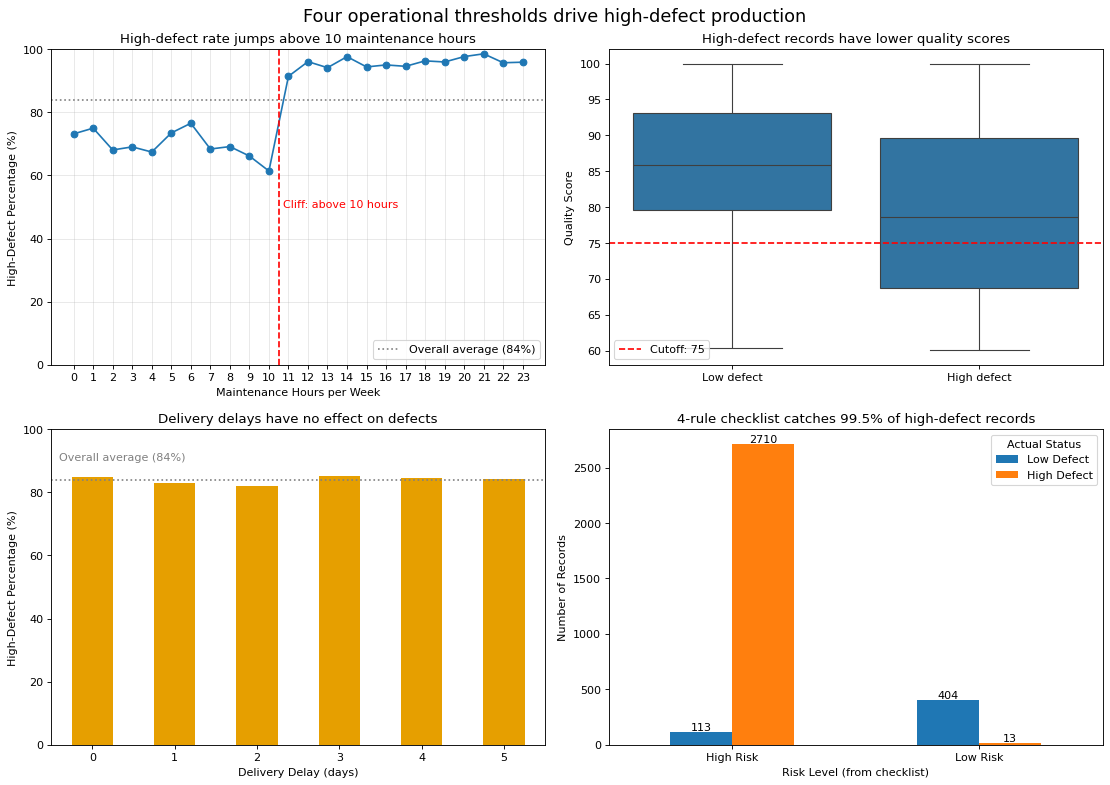

In [16]:
hourly = (
    df_defects.groupby('MaintenanceHours')['DefectStatus'].mean() * 100
).reset_index(name='high_defect_percentage')

delivery_table = pd.crosstab(
    df_defects['DeliveryDelay'], df_defects['DefectStatus'], normalize='index'
) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: maintenance tipping point
axes[0, 0].plot(hourly['MaintenanceHours'], hourly['high_defect_percentage'], marker='o')
axes[0, 0].set_title('High-defect rate jumps above 10 maintenance hours')
axes[0, 0].set_xlabel('Maintenance Hours per Week')
axes[0, 0].set_ylabel('High-Defect Percentage (%)')
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(0, 100)
axes[0, 0].axvline(10.5, color='red', linestyle='--')
axes[0, 0].text(10.7, 50, 'Cliff: above 10 hours', color='red')
axes[0, 0].axhline(84, color='grey', linestyle=':', label='Overall average (84%)')
axes[0, 0].legend(loc='lower right')

# Chart 2: quality score
sns.boxplot(data=df_defects, x='DefectStatus', y='QualityScore', ax=axes[0, 1])
axes[0, 1].set_title('High-defect records have lower quality scores')
axes[0, 1].set_xticks([0, 1], ['Low defect', 'High defect'])
axes[0, 1].axhline(75, color='red', linestyle='--', label='Cutoff: 75')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Quality Score')
axes[0, 1].legend(loc='lower left')

# Chart 3: delivery delay (no effect)
delivery_table[1].plot(kind='bar', ax=axes[1, 0], rot=0, color='#E69F00')
axes[1, 0].axhline(84, color='grey', linestyle=':')
axes[1, 0].text(-0.4, 90, 'Overall average (84%)', color='grey')
axes[1, 0].set_ylim(0, 100)
axes[1, 0].set_title('Delivery delays have no effect on defects')
axes[1, 0].set_xlabel('Delivery Delay (days)')
axes[1, 0].set_ylabel('High-Defect Percentage (%)')

# Chart 4: risk rule vs actual
risk_table.plot(kind='bar', ax=axes[1, 1], rot=0)
axes[1, 1].set_title('4-rule checklist catches 99.5% of high-defect records')
axes[1, 1].set_xlabel('Risk Level (from checklist)')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].legend(['Low Defect', 'High Defect'], title='Actual Status')
for bars in axes[1, 1].containers:
    axes[1, 1].bar_label(bars)

plt.suptitle('Four operational thresholds drive high-defect production', fontsize=16)
plt.tight_layout()
plt.savefig('../images/dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

1. **The high-defect label is a checklist of four operational thresholds** — maintenance > 10 hours, quality score < 75, production volume > 800, defect rate > 3. Together they explain 99.5% of high-defect records; a decision tree given all 16 factors found the same four rules on its own.
2. **Production volume is the most actionable lever**: run size is planned in advance, so it can't be a result of defects.
3. **Maintenance hours are a warning sign, not a cause** — flag equipment above 10 hours for investigation; don't cut maintenance.
4. **Supplier quality and delivery delays have no effect**, confirmed formally for delivery delay (chi-square p = 0.68).
5. **Confirm the label's definition** with whoever created it before using it for decisions.

*Caveat: the dataset is synthetic, so these findings demonstrate method, not facts about a real plant.*